<a href="https://colab.research.google.com/github/Maanvijangir/Github-demo/blob/main/crop_diseases.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Mounting dataset**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Extract data from zip file

In [ ]:
!unzip -q /content/drive/MyDrive/archive.zip -d /content/drive/MyDrive/unzipped_data

unzip:  cannot find or open /content/drive/MyDrive/archive.zip/test, /content/drive/MyDrive/archive.zip/test.zip or /content/drive/MyDrive/archive.zip/test.ZIP.


Extracting specific dir from file

In [ ]:
!unzip -q /content/drive/MyDrive/archive.zip "test/*" -d /content/drive/MyDrive/unzipped_data

Verifying dataset in available on drive or not


In [ ]:
!ls /content/drive/MyDrive/'New Plant Diseases Dataset(Augmented)'
!ls /content/drive/MyDrive/unzipped_data/'New Plant Diseases Dataset(Augmented)'/'New Plant Diseases Dataset(Augmented)'


'New Plant Diseases Dataset(Augmented)'
train  valid


Verifying dataset

In [ ]:


!ls /content/drive/MyDrive/unzipped_data/test | wc -l
!ls /content/drive/MyDrive/unzipped_data/'New Plant Diseases Dataset(Augmented)'/'New Plant Diseases Dataset(Augmented)'/valid | wc -l
!ls /content/drive/MyDrive/unzipped_data/'New Plant Diseases Dataset(Augmented)'/'New Plant Diseases Dataset(Augmented)'/train | head


1
38
Apple___Apple_scab
Apple___Black_rot
Apple___Cedar_apple_rust
Apple___healthy
Blueberry___healthy
Cherry_(including_sour)___healthy
Cherry_(including_sour)___Powdery_mildew
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Corn_(maize)___Common_rust_
Corn_(maize)___healthy


In [ ]:
!rm -rf /content/drive/MyDrive/unzipped_data/'new plant diseases dataset(augmented)'


In [ ]:
!unzip -q /content/drive/MyDrive/archive.zip "new plant diseases dataset(augmented)/*" -d /content/drive/MyDrive/unzipped_data

To load dataset locally on colab

In [2]:
!cp /content/drive/MyDrive/archive.zip /content/dataset.zip
!unzip -q /content/dataset.zip -d /content/unzipped_data
!rm /content/dataset.zip

Finally starting the process

# **Importing Libraries**

In [3]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# **Data Preprocessing**

Training img Preprocessing

In [4]:
training_set = tf.keras.utils.image_dataset_from_directory(
    '/content/unzipped_data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)


Found 70295 files belonging to 38 classes.


Validation Img Preprocessing

In [5]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    '/content/unzipped_data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)


Found 70295 files belonging to 38 classes.


In [ ]:
training_set

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 38), dtype=tf.float32, name=None))>

In [ ]:
for x,y in training_set:
  print(x,x.shape)
  print(y,y.shape)
  break

tf.Tensor(
[[[[147.   178.    98.  ]
   [136.25 167.25  87.25]
   [128.75 159.75  81.75]
   ...
   [211.   227.   190.  ]
   [205.25 221.25 185.25]
   [203.   219.   183.  ]]

  [[154.5  186.5  103.5 ]
   [141.   172.    92.  ]
   [131.75 162.75  82.75]
   ...
   [208.25 224.25 187.25]
   [202.75 218.75 182.75]
   [204.5  220.5  184.5 ]]

  [[157.   189.   104.  ]
   [142.5  174.5   91.5 ]
   [136.5  167.5   87.5 ]
   ...
   [208.75 224.75 188.75]
   [198.75 214.75 178.75]
   [203.25 218.25 185.25]]

  ...

  [[ 49.    79.25  52.  ]
   [ 35.75  70.75  34.5 ]
   [ 51.5   90.25  41.25]
   ...
   [176.25 204.25 154.75]
   [172.5  202.5  149.  ]
   [177.5  208.25 152.  ]]

  [[ 27.75  57.    35.  ]
   [ 24.25  58.25  27.75]
   [ 53.75  92.25  46.25]
   ...
   [178.   206.   157.25]
   [173.5  203.5  151.  ]
   [177.75 207.75 153.75]]

  [[ 29.75  58.75  39.75]
   [ 28.75  62.25  34.25]
   [ 47.    84.5   42.  ]
   ...
   [178.   206.   157.5 ]
   [173.   203.   151.5 ]
   [176.75 206.75 15

In [ ]:
for x, y in training_set.take(1):
    print("Images batch shape:", x.shape)
    print("Labels batch shape:", y.shape)
    print("First 5 labels:", y[:5].numpy())


Images batch shape: (32, 128, 128, 3)
Labels batch shape: (32, 38)
First 5 labels: [[0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]]


# **Building Model**

##To avoid Overshooting
 Choose small learning rate default 0.001 we are taking 0.0001



In [6]:
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.models import Sequential

In [7]:
model = Sequential()

Simple Dense NueralNnetwork(MLP)

In [ ]:
model2 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(128,128,3)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128,activation='relu'),
    tf.keras.layers.Dense(38,activation='softmax')
])

Recurrent Nueral Network is not used bcoz data is not sequential

building convolutional layer

In [8]:
model.add(Conv2D(filters=32,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
model.add(Conv2D(filters=32,kernel_size=3,padding='same',activation='relu'))
model.add(MaxPooling2D(pool_size=2,strides=2))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.add(Conv2D(filters=64,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
model.add(Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
model.add(MaxPooling2D(pool_size=2,strides=2))

In [10]:
model.add(Conv2D(filters=128,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
model.add(Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
model.add(MaxPooling2D(pool_size=2,strides=2))

In [11]:
model.add(Conv2D(filters=256,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
model.add(Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
model.add(MaxPooling2D(pool_size=2,strides=2))

In [12]:
model.add(Flatten())

In [13]:
model.add(Dense(units=1024,activation='relu')) #dense layer is basically our hidden layer & units are the number of nueron we want

In [14]:
model.add(Dense(units=38,activation='softmax')) #output layer

Compiling model

In [15]:
model.compile(optimizer=tf.keras.optimizers.Adam(
    learning_rate=0.0001),loss='categorical_crossentropy',metrics=['accuracy'])

In [ ]:
model2.compile(optimizer=tf.keras.optimizers.Adam(
    learning_rate=0.0001, clipnorm=1.0),loss='categorical_crossentropy',metrics=['accuracy'])

In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │    16,778,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │        38,950 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,989,446 (68.62 MB)

 Trainable params: 17,989,446 (68.62 MB)

 Non-trainable params: 0 (0.00 B)

# Model Training

In [16]:
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

In [17]:
training_history = model.fit(x=training_set,validation_data=validation_set,epochs=5)

Epoch 1/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 218s 93ms/step - accuracy: 0.7670 - loss: 0.8047 - val_accuracy: 0.9282 - val_loss: 0.2319
Epoch 2/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 170s 78ms/step - accuracy: 0.9307 - loss: 0.2136 - val_accuracy: 0.9577 - val_loss: 0.1313
Epoch 3/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 169s 77ms/step - accuracy: 0.9612 - loss: 0.1173 - val_accuracy: 0.9789 - val_loss: 0.0617
Epoch 4/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 205s 93ms/step - accuracy: 0.9747 - loss: 0.0768 - val_accuracy: 0.9841 - val_loss: 0.0473
Epoch 5/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 206s 94ms/step - accuracy: 0.9804 - loss: 0.0597 - val_accuracy: 0.9726 - val_loss: 0.0815


In [ ]:
training_history2 = model2.fit(x=training_set,validation_data=validation_set,epochs=10)

Epoch 1/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 99s 44ms/step - accuracy: 0.0808 - loss: 3.5241 - val_accuracy: 0.1157 - val_loss: 3.2800
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 95s 43ms/step - accuracy: 0.1180 - loss: 3.2306 - val_accuracy: 0.1467 - val_loss: 3.0990
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 97s 44ms/step - accuracy: 0.1518 - loss: 3.0560 - val_accuracy: 0.1734 - val_loss: 2.9233
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 104s 47ms/step - accuracy: 0.1857 - loss: 2.8906 - val_accuracy: 0.2046 - val_loss: 2.7847
Epoch 5/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 96s 43ms/step - accuracy: 0.2114 - loss: 2.7653 - val_accuracy: 0.2277 - val_loss: 2.6836
Epoch 6/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 114s 52ms/step - accuracy: 0.2437 - loss: 2.6540 - val_accuracy: 0.2781 - val_loss: 2.5498
Epoch 7/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 118s 54ms/step - accuracy: 0.2888 - loss: 2.5210 - val_accuracy: 0.2985 - val_loss: 2.4818
Epoch 8/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 108s 49ms/step - accuracy: 0.31

Plotting the data to compare

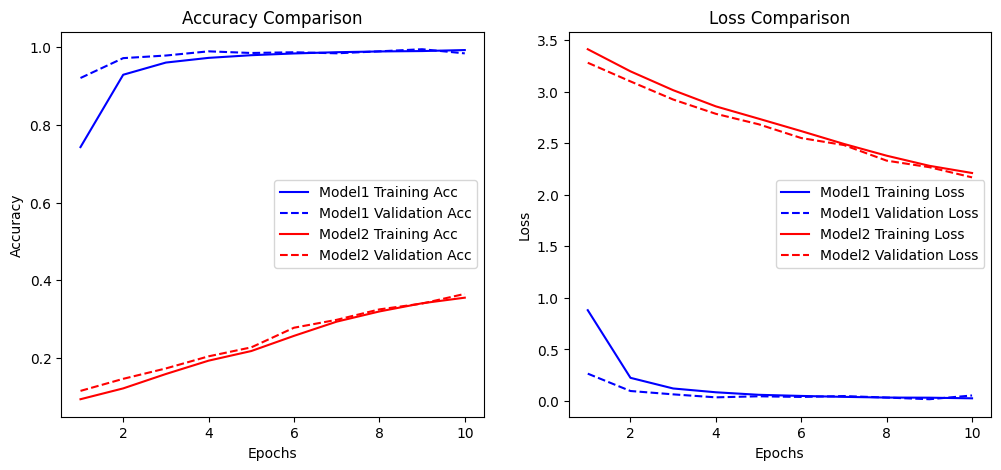

In [ ]:

acc = training_history.history['accuracy']
val_acc = training_history.history['val_accuracy']
loss = training_history.history['loss']
val_loss = training_history.history['val_loss']

acc2 = training_history2.history['accuracy']
val_acc2 = training_history2.history['val_accuracy']
loss2 = training_history2.history['loss']
val_loss2 = training_history2.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs, acc, 'b-', label='Model1 Training Acc')
plt.plot(epochs, val_acc, 'b--', label='Model1 Validation Acc')
plt.plot(epochs, acc2, 'r-', label='Model2 Training Acc')
plt.plot(epochs, val_acc2, 'r--', label='Model2 Validation Acc')
plt.title('Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1,2,2)
plt.plot(epochs, loss, 'b-', label='Model1 Training Loss')
plt.plot(epochs, val_loss, 'b--', label='Model1 Validation Loss')
plt.plot(epochs, loss2, 'r-', label='Model2 Training Loss')
plt.plot(epochs, val_loss2, 'r--', label='Model2 Validation Loss')
plt.title('Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()



##Model evaluation

Model evaluation on training set

In [18]:
train_loss, train_acc = model.evaluate(training_set)

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 49s 22ms/step - accuracy: 0.9726 - loss: 0.0815


In [ ]:
print(train_loss, train_acc)

0.009482032619416714 0.9970837235450745


 Model evaluation on validation set

In [19]:
val_loss, val_acc = model.evaluate(validation_set)

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 51s 23ms/step - accuracy: 0.9726 - loss: 0.0815


In [ ]:
print(val_loss, val_acc)

0.009482035413384438 0.9970837235450745


Saving model

we can also use .h5 format but .keras compress the file so that we can easily use it

In [24]:
model.save("/content/drive/MyDrive/trained_model.keras")


In [25]:
training_history.history

{'accuracy': [0.7485738396644592,
  0.9254000782966614,
  0.9575503468513489,
  0.9728572368621826,
  0.9789743423461914,
  0.9838253259658813,
  0.9864855408668518,
  0.9889750480651855,
  0.9892879724502563,
  0.9912084937095642],
 'loss': [0.8674485087394714,
  0.22875267267227173,
  0.1266745626926422,
  0.08262453973293304,
  0.06343495845794678,
  0.049574706703424454,
  0.04167025163769722,
  0.03321785479784012,
  0.0327577069401741,
  0.02778712473809719],
 'val_accuracy': [0.9066078662872314,
  0.9365246295928955,
  0.9813926815986633,
  0.9823315739631653,
  0.9859307408332825,
  0.9920193552970886,
  0.9901842474937439,
  0.9919482469558716,
  0.9826018810272217,
  0.9955188632011414],
 'val_loss': [0.2986653745174408,
  0.19363847374916077,
  0.058342888951301575,
  0.05357782915234566,
  0.04355410858988762,
  0.024568922817707062,
  0.030902910977602005,
  0.024861011654138565,
  0.055148616433143616,
  0.014491640031337738]}

Recording history in json

In [26]:
import json
import os
with open("/content/drive/MyDrive/training_history.json", "w") as f:
    json.dump(training_history.history, f)

Accuracy visualization

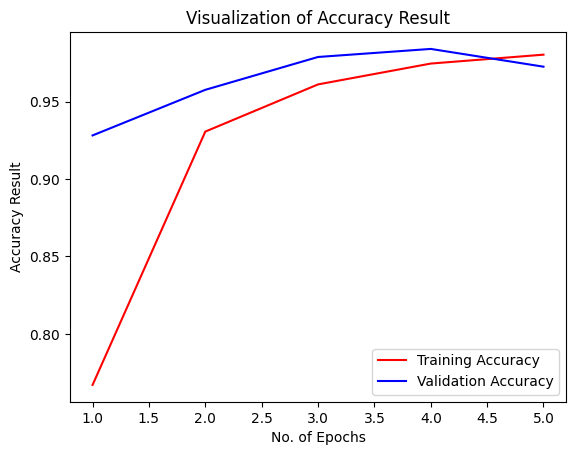

In [20]:
epochs = list(range(1, len(training_history.history['accuracy'])+1))
plt.plot(epochs, training_history.history['accuracy'],color='red',label='Training Accuracy')
plt.plot(epochs, training_history.history['val_accuracy'],color='blue',label='Validation Accuracy' )
plt.xlabel("No. of Epochs")
plt.ylabel("Accuracy Result")
plt.title("Visualization of Accuracy Result")
plt.legend()
plt.show()

Some other matrics for model evaluation

In [21]:
class_name = validation_set.class_names
class_name

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_

In [22]:
test_set = tf.keras.utils.image_dataset_from_directory(
    '/content/unzipped_data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)

Found 17572 files belonging to 38 classes.


In [24]:
y_pred = model.predict(test_set)
y_pred,y_pred.shape

550/550 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step


(array([[9.9998569e-01, 4.2963684e-08, 1.4843526e-11, ..., 3.4657268e-12,
         3.8811595e-14, 1.1903172e-08],
        [9.9999881e-01, 6.5162340e-08, 1.5663835e-11, ..., 3.7070516e-15,
         7.4701354e-14, 5.3962346e-09],
        [9.9998558e-01, 4.6084683e-08, 5.8993088e-10, ..., 1.7864982e-13,
         5.2518016e-13, 1.5590684e-08],
        ...,
        [2.6897287e-09, 2.6139238e-10, 3.1142362e-09, ..., 1.9918900e-10,
         2.2302027e-10, 9.9995446e-01],
        [2.2754344e-08, 9.0297919e-13, 6.5913781e-11, ..., 1.5409772e-10,
         6.7234011e-13, 9.9999917e-01],
        [2.9941807e-17, 8.4242570e-21, 3.4220452e-17, ..., 1.3043912e-20,
         1.5663435e-14, 9.9999952e-01]], dtype=float32),
 (17572, 38))

axis=1 in column wise operation and axis=0 is row wise

In [25]:
predicted_categories = tf.argmax(y_pred, axis=1)
predicted_categories,predicted_categories.shape

(<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37])>,
 TensorShape([17572]))

In [27]:
true_categories = tf.concat([y for x,y in test_set],axis=0)
true_categories,true_categories.shape


(<tf.Tensor: shape=(17572, 38), dtype=float32, numpy=
 array([[1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 1.],
        [0., 0., 0., ..., 0., 0., 1.],
        [0., 0., 0., ..., 0., 0., 1.]], dtype=float32)>,
 TensorShape([17572, 38]))

In [28]:
y_true = tf.argmax(true_categories, axis=1)
y_true,y_true.shape

(<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37])>,
 TensorShape([17572]))

In [31]:
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_true,predicted_categories,target_names=class_name))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.93      0.94      0.94       504
                                 Apple___Black_rot       0.97      0.98      0.97       497
                          Apple___Cedar_apple_rust       0.97      0.96      0.96       440
                                   Apple___healthy       0.89      0.96      0.92       502
                               Blueberry___healthy       0.91      0.98      0.94       454
          Cherry_(including_sour)___Powdery_mildew       0.98      0.98      0.98       421
                 Cherry_(including_sour)___healthy       0.96      0.99      0.97       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.96      0.82      0.88       410
                       Corn_(maize)___Common_rust_       0.98      0.99      0.99       477
               Corn_(maize)___Northern_Leaf_Blight       0.89      0.96      0.

In [33]:
cm  = confusion_matrix(y_true,predicted_categories)
cm,cm.shape

(array([[476,   5,   1, ...,   0,   0,   1],
        [  1, 486,   0, ...,   0,   1,   0],
        [  1,   0, 422, ...,   0,   0,   3],
        ...,
        [  0,   0,   1, ..., 436,   3,   1],
        [  0,   0,   0, ...,   0, 445,   0],
        [  0,   0,   1, ...,   0,   0, 468]]),
 (38, 38))

confusion matrix visualization

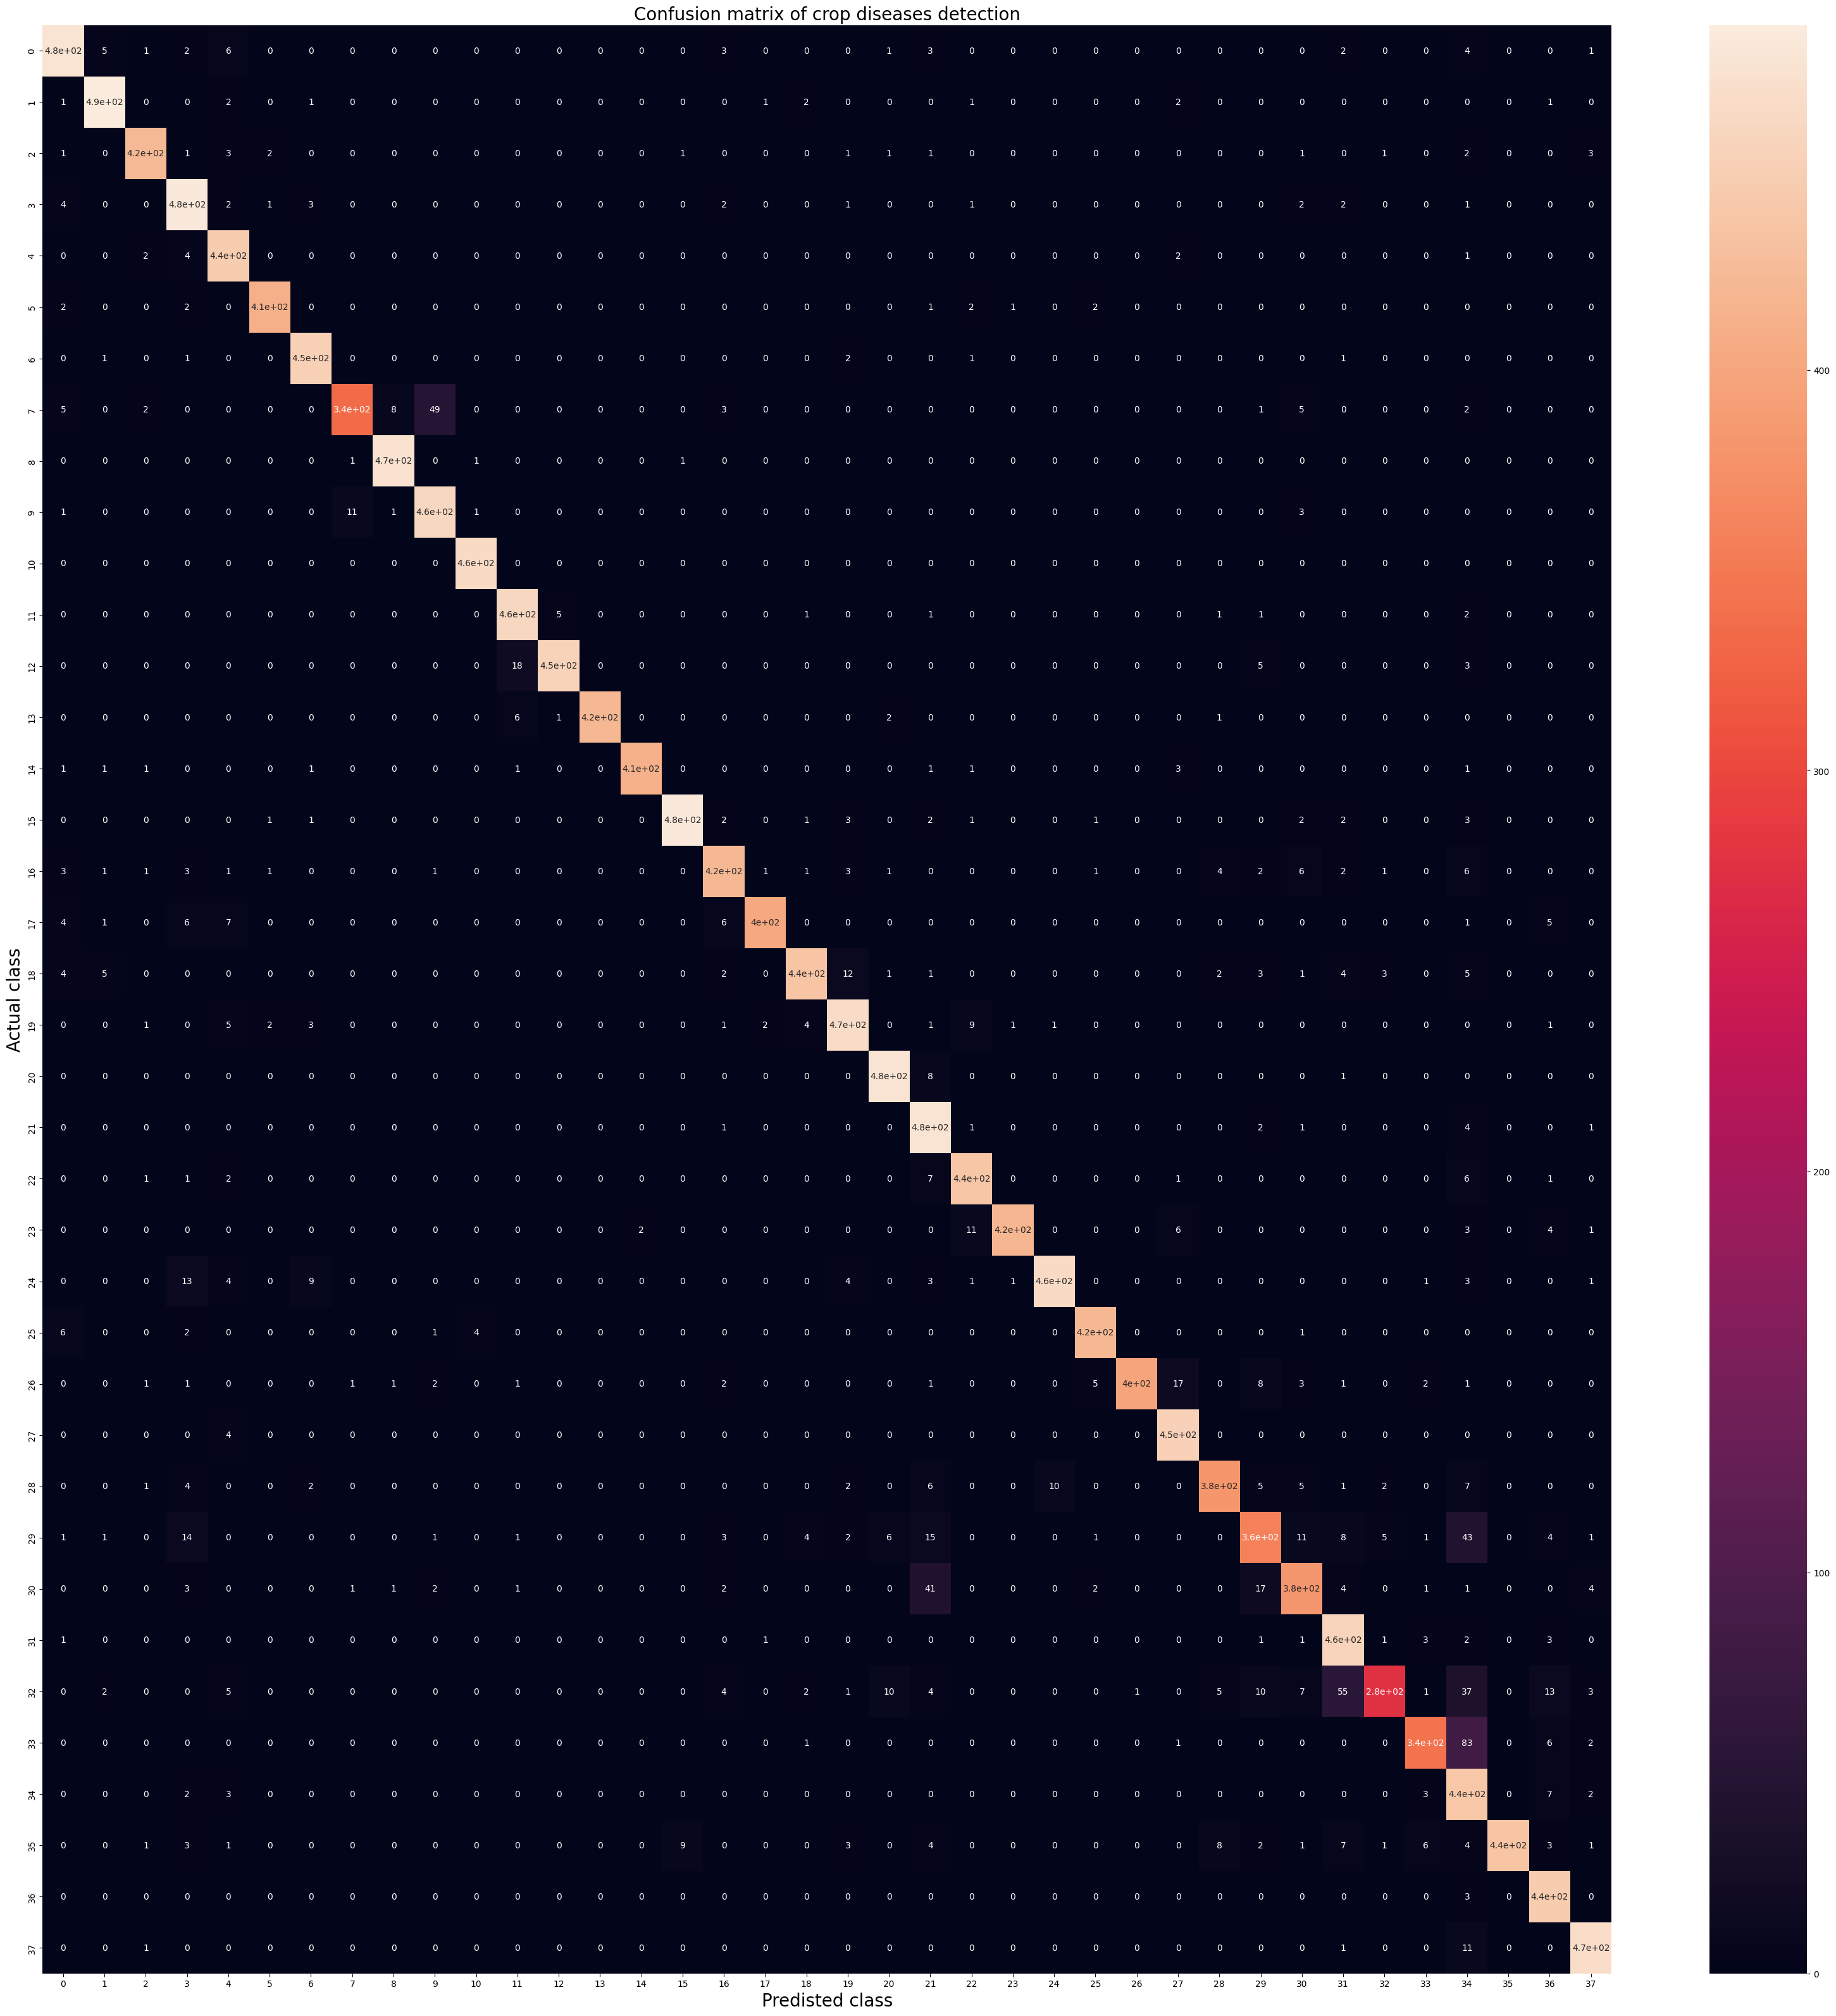

In [41]:
plt.figure(figsize=(40,40))
sns.heatmap(cm,annot=True,annot_kws={'size':10})
plt.xlabel("Predisted class",fontsize=20)
plt.ylabel("Actual class",fontsize=20)
plt.title("Confusion matrix of crop diseases detection",fontsize=20)
plt.show()